# 📊 Bivariate Analysis

> **Folder:** `02_Exploratory_Data_Analysis / Bivariate_Analysis`  
> **Notebook:** `bivariate_analysis.ipynb`  
> **Author:** Hamna Munir

---

## 🎯 Objectives

By the end of this notebook, you will:

- Analyze relationships between **Numerical vs Numerical** variables
- Compare distributions across groups — **Numerical vs Categorical**
- Detect associations between **Categorical vs Categorical** variables
- Perform **ML-focused EDA** — feature vs target analysis
- Apply the correct **statistical tests** for each variable pair type
- Build a complete **bivariate EDA summary report**

---

## 📚 Techniques Covered

| # | Technique | Pair Type |
|---|-----------|----------:|
| 1 | Scatter Plot + Regression Line | Num vs Num |
| 2 | Pearson & Spearman Correlation | Num vs Num |
| 3 | Box Plot by Group | Num vs Cat |
| 4 | Violin Plot by Group | Num vs Cat |
| 5 | Mean Bar Chart with Error Bars | Num vs Cat |
| 6 | t-Test & Mann-Whitney U | Num vs Cat (2 groups) |
| 7 | ANOVA & Kruskal-Wallis | Num vs Cat (3+ groups) |
| 8 | Cross-Tabulation + Heatmap | Cat vs Cat |
| 9 | Stacked & Grouped Bar Charts | Cat vs Cat |
| 10 | Chi-Square + Cramér's V | Cat vs Cat |
| 11 | KDE by Target Class | Num vs Target |
| 12 | Churn Rate by Category | Cat vs Target |
| 13 | Point-Biserial Correlation | Num vs Binary Target |
| 14 | Bivariate EDA Report | All pairs |

---
## ⚙️ 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import stats
from scipy.stats import (
    pearsonr, spearmanr, ttest_ind, mannwhitneyu,
    f_oneway, kruskal, chi2_contingency, pointbiserialr
)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

COLORS = {
    'primary'  : '#2E86AB',
    'secondary': '#E84855',
    'accent'   : '#3BB273',
    'warning'  : '#F18F01',
    'purple'   : '#7B2D8B',
    'palette'  : ['#2E86AB','#E84855','#3BB273','#F18F01','#7B2D8B','#F4D35E'],
}

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


---
## 📊 1. Load & Inspect Dataset

In [2]:
np.random.seed(42)
n = 600

edu_levels = ["High School", "Bachelor's", "Master's", "PhD"]
edu_probs  = [0.25, 0.40, 0.25, 0.10]
education  = np.random.choice(edu_levels, n, p=edu_probs)

# Salary correlated with education
edu_salary_map = {"High School": 35_000, "Bachelor's": 60_000,
                  "Master's": 90_000,   "PhD": 120_000}
base_salary = np.array([edu_salary_map[e] for e in education])

df = pd.DataFrame({
    'Age'         : np.random.randint(22, 65, n),
    'Salary'      : (base_salary + np.random.normal(0, 15_000, n)).clip(20_000, 200_000),
    'Score'       : np.random.normal(65, 12, n).clip(0, 100),
    'Experience'  : np.random.randint(0, 30, n),
    'Income'      : np.random.exponential(50_000, n),
    'Num_Products': np.random.randint(1, 15, n),
    'Education'   : education,
    'City'        : np.random.choice(['London','Paris','Berlin','Tokyo','Sydney'], n,
                                      p=[0.35,0.25,0.20,0.12,0.08]),
    'Gender'      : np.random.choice(['Male','Female','Non-Binary'], n,
                                      p=[0.48,0.48,0.04]),
    'Churn'       : np.random.choice([0,1], n, p=[0.78,0.22]),
})

# Make Score partially correlated with Salary
df['Score'] = (df['Score'] + df['Salary'] / 5000).clip(0, 100)

num_cols = ['Age','Salary','Score','Experience','Income','Num_Products']
cat_cols = ['Education','City','Gender']
target   = 'Churn'

print(f'Shape: {df.shape}')
df.head()

Shape: (600, 10)


,Age,Salary,Score,Experience,Income,Num_Products,Education,City,Gender,Churn
0,26,73016.4754,70.2227,14,17527.1658,13,Bachelor's,Paris,Female,0
1,39,124245.4831,100.0000,27,45045.7869,13,PhD,Tokyo,Female,0
2,49,69758.0464,86.2372,1,1667.9965,2,Master's,Tokyo,Male,0
3,63,68782.5519,94.4904,6,50535.9045,5,Bachelor's,Paris,Female,0
4,43,45700.9939,59.1091,2,22655.6925,1,High School,Paris,Male,0


---
## PART A — Numerical vs Numerical
---
## 1️⃣ Scatter Plot + Regression Line

> Each point represents one observation. The regression line shows the overall trend.
>
> ✅ **Always plot before computing correlation** — the scatter reveals patterns  
> that a single number (r) cannot capture.

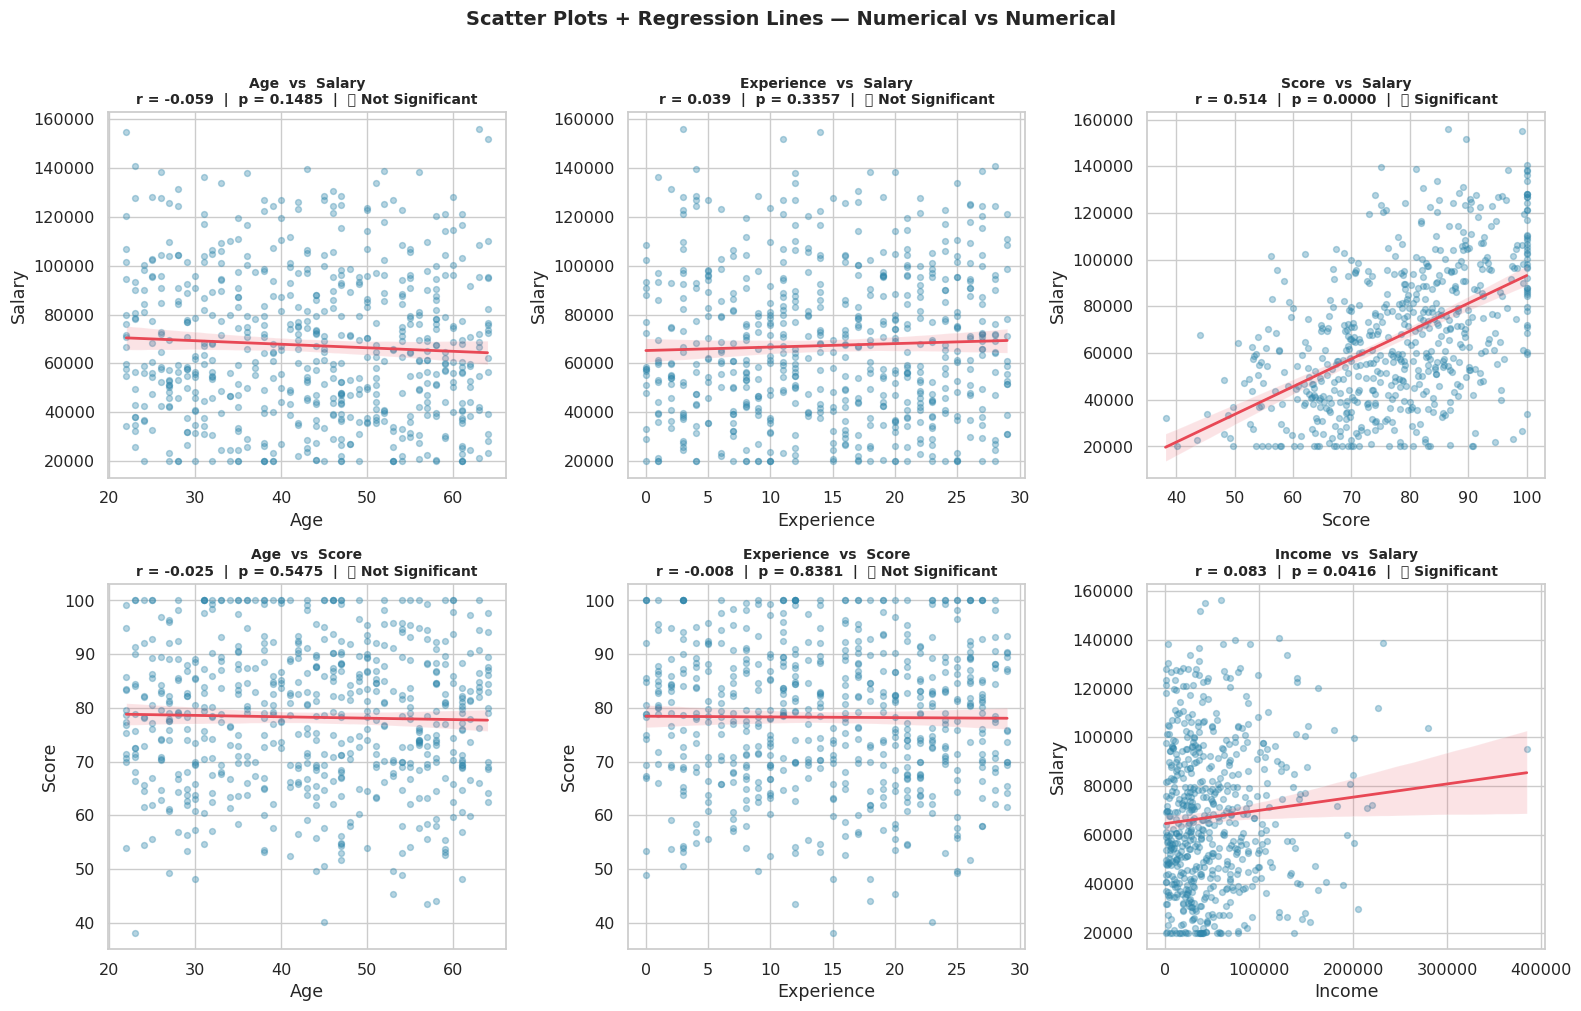

In [3]:
pairs = [
    ('Age',        'Salary'),
    ('Experience', 'Salary'),
    ('Score',      'Salary'),
    ('Age',        'Score'),
    ('Experience', 'Score'),
    ('Income',     'Salary'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (x_col, y_col) in zip(axes, pairs):
    r, p = pearsonr(df[x_col].dropna(), df[y_col].dropna())

    sns.regplot(
        data=df, x=x_col, y=y_col, ax=ax,
        scatter_kws=dict(alpha=0.35, s=18, color=COLORS['primary']),
        line_kws=dict(color=COLORS['secondary'], linewidth=2),
        ci=95
    )
    sig = '✅ Significant' if p < 0.05 else '❌ Not Significant'
    ax.set_title(f'{x_col}  vs  {y_col}\nr = {r:.3f}  |  p = {p:.4f}  |  {sig}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)

plt.suptitle('Scatter Plots + Regression Lines — Numerical vs Numerical',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 2️⃣ Pearson & Spearman Correlation

> **Pearson** — linear relationships on normally distributed data.  
> **Spearman** — monotonic relationships, robust to outliers and non-normal data.
>
> ✅ Compare both — a big gap between them signals a non-linear pattern.

In [4]:
corr_rows = []
for x_col, y_col in pairs:
    data     = df[[x_col, y_col]].dropna()
    p_r, p_p = pearsonr(data[x_col],  data[y_col])
    s_r, s_p = spearmanr(data[x_col], data[y_col])

    def interpret(r):
        a = abs(r)
        d = 'Positive' if r > 0 else 'Negative'
        if a >= 0.70: return f'Strong {d}'
        if a >= 0.40: return f'Moderate {d}'
        if a >= 0.10: return f'Weak {d}'
        return 'Negligible'

    corr_rows.append({
        'X'               : x_col,
        'Y'               : y_col,
        'Pearson r'       : round(p_r, 4),
        'Pearson p'       : round(p_p, 4),
        'Spearman ρ'      : round(s_r, 4),
        'Spearman p'      : round(s_p, 4),
        'Interpretation'  : interpret(p_r),
        'Significant'     : '✅' if p_p < 0.05 else '❌',
    })

corr_df = pd.DataFrame(corr_rows)
print('Pearson & Spearman Correlation Summary:')
corr_df

Pearson & Spearman Correlation Summary:


,X,Y,Pearson r,Pearson p,Spearman ρ,Spearman p,Interpretation,Significant
0,Age,Salary,-0.0591,0.1485,-0.0600,0.1424,Negligible,❌
1,Experience,Salary,0.0394,0.3357,0.0458,0.2625,Negligible,❌
2,Score,Salary,0.5142,0.0000,0.5137,0.0000,Moderate Positive,✅
3,Age,Score,-0.0246,0.5475,-0.0189,0.6446,Negligible,❌
4,Experience,Score,-0.0084,0.8381,-0.0057,0.8896,Negligible,❌
5,Income,Salary,0.0832,0.0416,0.0558,0.1724,Negligible,✅


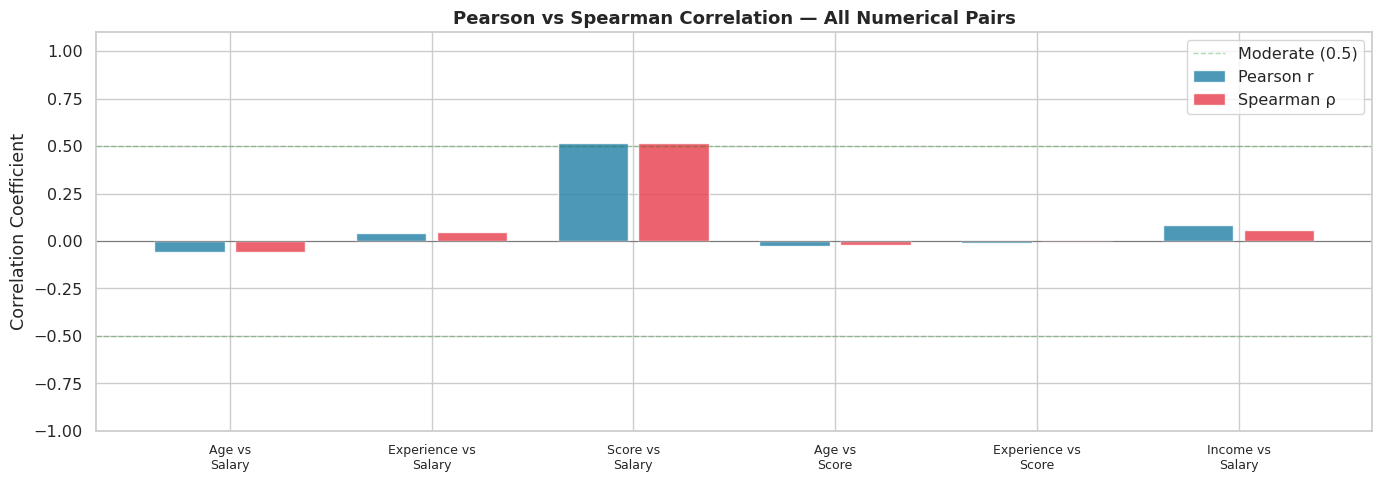

In [5]:
# ── Side-by-side Pearson vs Spearman ─────────────────────────────────────
x_labels = [f"{r['X']} vs\n{r['Y']}" for _, r in corr_df.iterrows()]
x_pos    = np.arange(len(corr_df))

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x_pos - 0.2, corr_df['Pearson r'],  0.35,
       label='Pearson r',  color=COLORS['primary'],  edgecolor='white', alpha=0.85)
ax.bar(x_pos + 0.2, corr_df['Spearman ρ'], 0.35,
       label='Spearman ρ', color=COLORS['secondary'], edgecolor='white', alpha=0.85)

ax.axhline(0,    color='black', linewidth=0.8, alpha=0.4)
ax.axhline(0.5,  color='green', linewidth=1,   alpha=0.3, linestyle='--', label='Moderate (0.5)')
ax.axhline(-0.5, color='green', linewidth=1,   alpha=0.3, linestyle='--')
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, fontsize=9)
ax.set_ylabel('Correlation Coefficient')
ax.set_ylim(-1, 1.1)
ax.set_title('Pearson vs Spearman Correlation — All Numerical Pairs',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## PART B — Numerical vs Categorical
---
## 3️⃣ Box Plot by Group

> Compares the distribution of a numerical variable across the categories of a  
> categorical variable using the 5-number summary + outliers.
>
> ✅ Best tool to quickly compare medians and spread across groups.

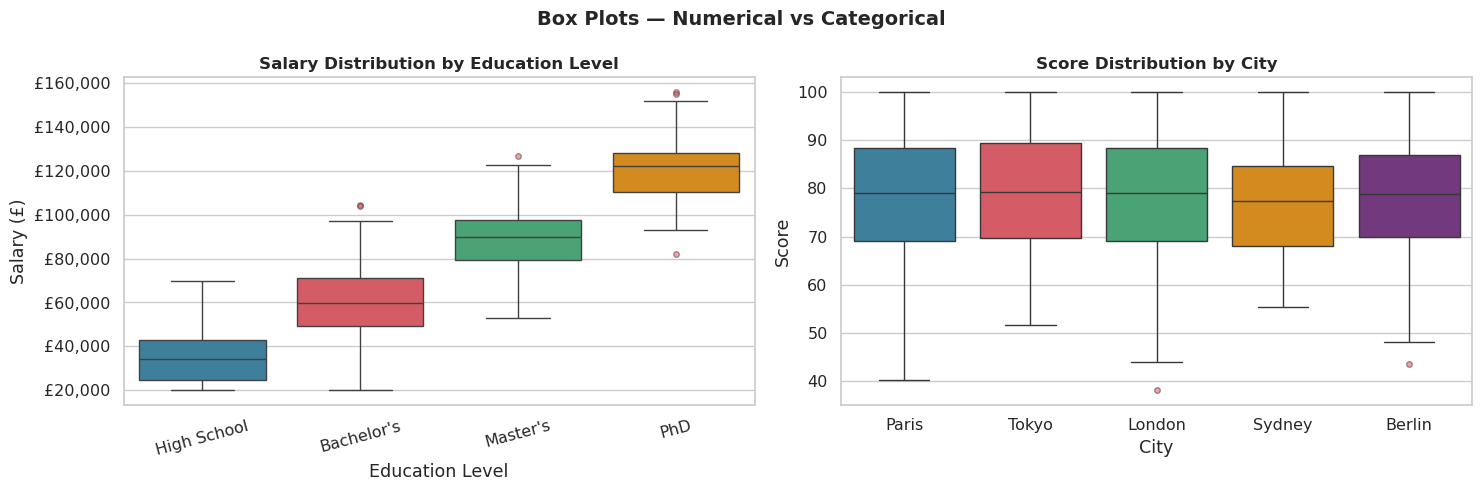

In [6]:
edu_order = ["High School", "Bachelor's", "Master's", "PhD"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Salary by Education
sns.boxplot(
    data=df, x='Education', y='Salary', order=edu_order,
    palette=COLORS['palette'][:4], ax=axes[0],
    flierprops=dict(marker='o', markerfacecolor=COLORS['secondary'],
                    markersize=4, alpha=0.5)
)
axes[0].set_title('Salary Distribution by Education Level',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Education Level')
axes[0].set_ylabel('Salary (£)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[0].tick_params(axis='x', rotation=15)

# Score by City
sns.boxplot(
    data=df, x='City', y='Score',
    palette=COLORS['palette'][:5], ax=axes[1],
    flierprops=dict(marker='o', markerfacecolor=COLORS['secondary'],
                    markersize=4, alpha=0.5)
)
axes[1].set_title('Score Distribution by City', fontsize=12, fontweight='bold')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Score')

plt.suptitle('Box Plots — Numerical vs Categorical', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4️⃣ Violin Plot by Group

> Extends the box plot by showing the **full distribution shape** — reveals bimodality  
> and irregular distribution patterns that box plots cannot show.
>
> ✅ Use when distribution shape matters, not just quartiles.

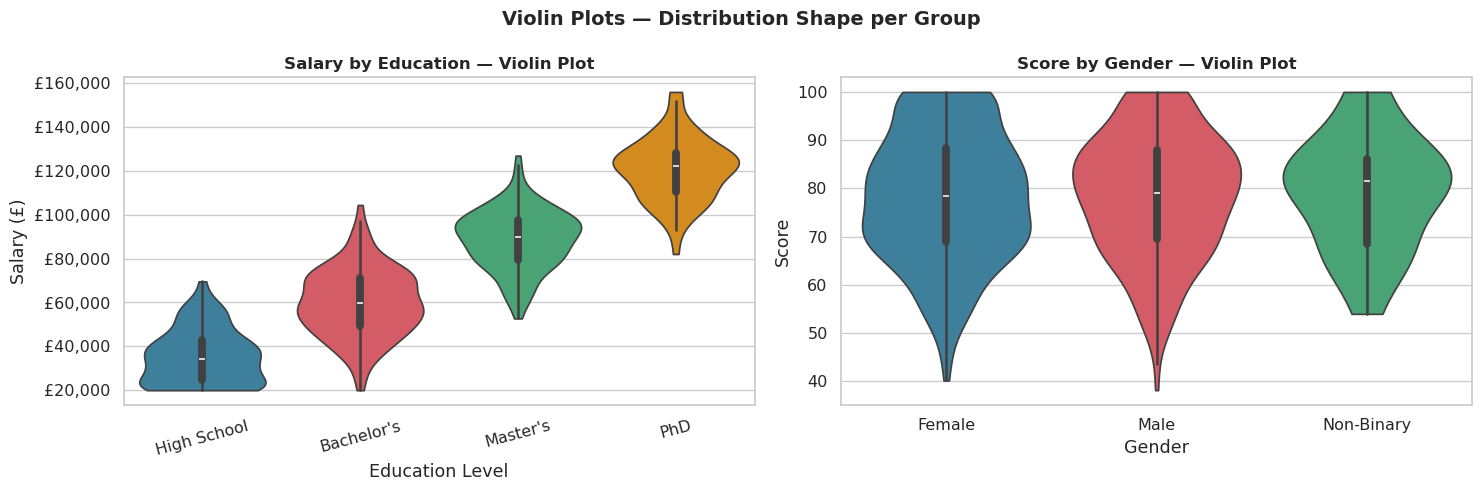

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.violinplot(
    data=df, x='Education', y='Salary', order=edu_order,
    palette=COLORS['palette'][:4], ax=axes[0],
    inner='box', cut=0
)
axes[0].set_title('Salary by Education — Violin Plot',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Education Level')
axes[0].set_ylabel('Salary (£)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[0].tick_params(axis='x', rotation=15)

sns.violinplot(
    data=df, x='Gender', y='Score',
    palette=COLORS['palette'][:3], ax=axes[1],
    inner='box', cut=0
)
axes[1].set_title('Score by Gender — Violin Plot', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Score')

plt.suptitle('Violin Plots — Distribution Shape per Group',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5️⃣ Mean Bar Chart with Error Bars

> Shows the **mean of a numerical variable per category** with ±1 standard deviation  
> as error bars — communicates both the average and the spread simultaneously.

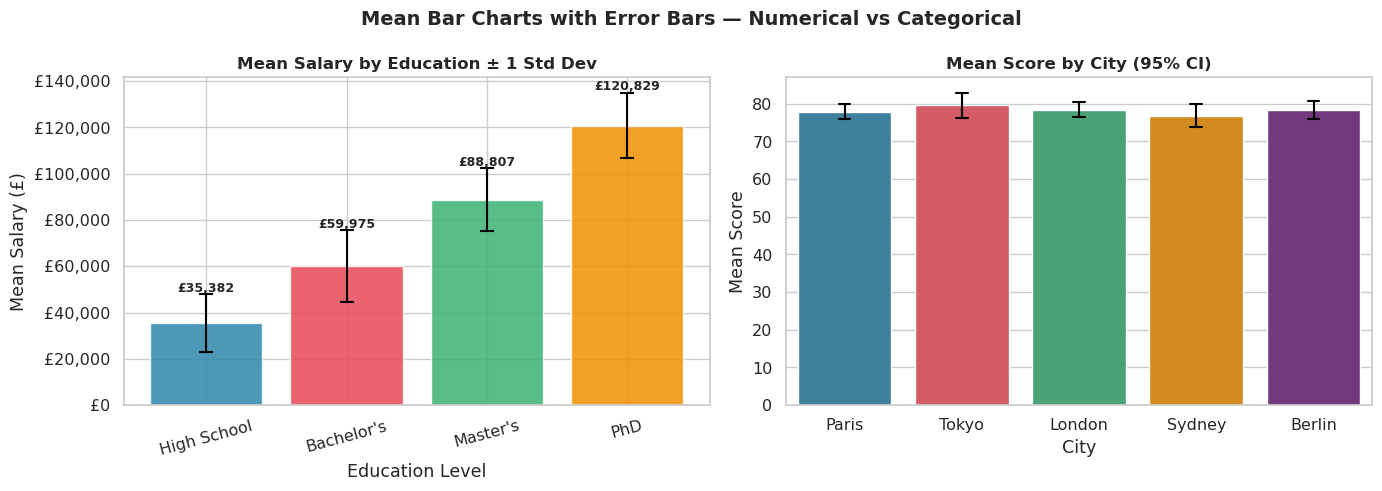

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Salary by Education — mean ± std
summary = df.groupby('Education')['Salary'].agg(['mean','std']).reindex(edu_order)

axes[0].bar(summary.index, summary['mean'],
             yerr=summary['std'], capsize=5,
             color=COLORS['palette'][:4], edgecolor='white', alpha=0.85,
             error_kw=dict(elinewidth=1.5, ecolor='black', capthick=1.5))
axes[0].set_title('Mean Salary by Education ± 1 Std Dev',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Education Level')
axes[0].set_ylabel('Mean Salary (£)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[0].tick_params(axis='x', rotation=15)
for i, (_, row) in enumerate(summary.iterrows()):
    axes[0].text(i, row['mean'] + row['std'] + 1000,
                 f'£{row["mean"]:,.0f}', ha='center', fontsize=9, fontweight='bold')

# Score by City — seaborn barplot (auto computes CI)
sns.barplot(data=df, x='City', y='Score', palette=COLORS['palette'][:5],
            ax=axes[1], capsize=0.1, errcolor='black', errwidth=1.5)
axes[1].set_title('Mean Score by City (95% CI)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Mean Score')

plt.suptitle('Mean Bar Charts with Error Bars — Numerical vs Categorical',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6️⃣ Statistical Tests — 2 Groups (t-Test & Mann-Whitney U)

> **t-Test** — parametric, assumes normality.  
> **Mann-Whitney U** — non-parametric, robust alternative for non-normal or small samples.
>
> ✅ Rule: `p < 0.05` → groups are significantly different.

═══════════════════════════════════════════════════════
 📋 Two-Group Significance Tests — Salary: Male vs Female
═══════════════════════════════════════════════════════
  Male   Salary → Mean: £   64,642  Median: £   60,832
  Female Salary → Mean: £   70,445  Median: £   68,579

  Student t-Test    → t=-2.3140  p=0.0210  ✅ Significant
  Mann-Whitney U    → U=37752  p=0.0394  ✅ Significant
═══════════════════════════════════════════════════════


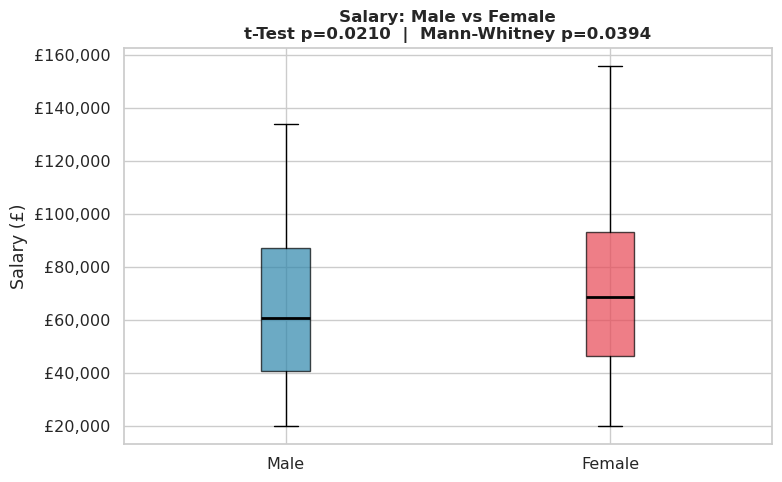

In [9]:
# Compare Salary: Male vs Female
male_salary   = df[df['Gender'] == 'Male']['Salary'].dropna()
female_salary = df[df['Gender'] == 'Female']['Salary'].dropna()

t_stat, t_p = ttest_ind(male_salary, female_salary)
u_stat, u_p = mannwhitneyu(male_salary, female_salary, alternative='two-sided')

print('═' * 55)
print(' 📋 Two-Group Significance Tests — Salary: Male vs Female')
print('═' * 55)
print(f'  Male   Salary → Mean: £{male_salary.mean():>9,.0f}  Median: £{male_salary.median():>9,.0f}')
print(f'  Female Salary → Mean: £{female_salary.mean():>9,.0f}  Median: £{female_salary.median():>9,.0f}')
print()
print(f'  Student t-Test    → t={t_stat:.4f}  p={t_p:.4f}  {"✅ Significant" if t_p < 0.05 else "❌ Not Significant"}')
print(f'  Mann-Whitney U    → U={u_stat:.0f}  p={u_p:.4f}  {"✅ Significant" if u_p < 0.05 else "❌ Not Significant"}')
print('═' * 55)

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
data_plot = [
    df[df['Gender'] == 'Male']['Salary'].dropna(),
    df[df['Gender'] == 'Female']['Salary'].dropna()
]
bp = ax.boxplot(data_plot, patch_artist=True, labels=['Male', 'Female'],
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], [COLORS['primary'], COLORS['secondary']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title(f'Salary: Male vs Female\nt-Test p={t_p:.4f}  |  Mann-Whitney p={u_p:.4f}',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Salary (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.show()

---
## 7️⃣ Statistical Tests — 3+ Groups (ANOVA & Kruskal-Wallis)

> **ANOVA** — tests whether means differ across 3+ groups (assumes normality).  
> **Kruskal-Wallis** — non-parametric equivalent, no normality assumption.
>
> ✅ Significant ANOVA/KW tells us *some* groups differ — use post-hoc tests to find *which* ones.

════════════════════════════════════════════════════════════
 📋 Multi-Group Tests — Salary Across Education Levels
════════════════════════════════════════════════════════════
  High School     → Mean: £   35,382  Median: £   34,399  n=155
  Bachelor's      → Mean: £   59,975  Median: £   59,619  n=235
  Master's        → Mean: £   88,807  Median: £   89,912  n=142
  PhD             → Mean: £  120,829  Median: £  122,048  n=68

  One-Way ANOVA     → F=710.5665  p=0.000000  ✅ Significant
  Kruskal-Wallis    → H=455.2476  p=0.000000  ✅ Significant
════════════════════════════════════════════════════════════


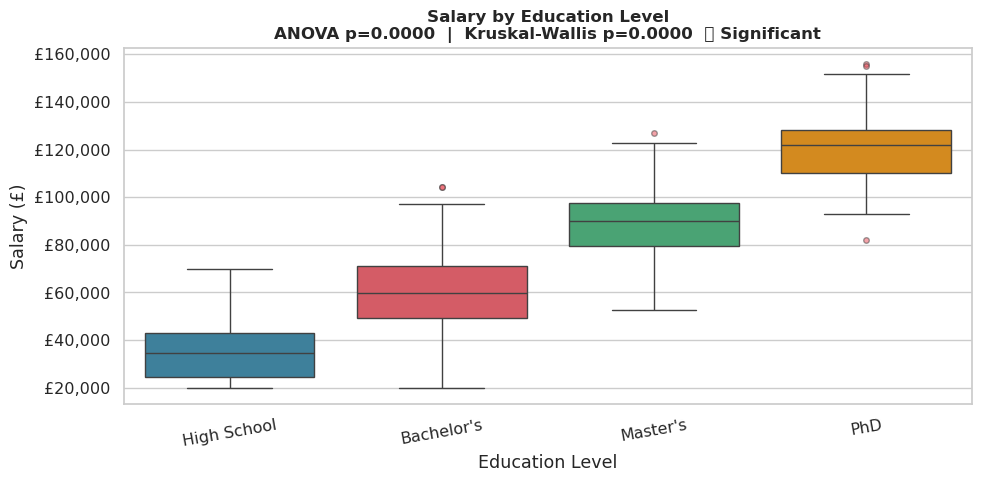

In [10]:
groups = [df[df['Education'] == edu]['Salary'].dropna() for edu in edu_order]

f_stat, anova_p = f_oneway(*groups)
h_stat, kw_p    = kruskal(*groups)

print('═' * 60)
print(' 📋 Multi-Group Tests — Salary Across Education Levels')
print('═' * 60)
for edu in edu_order:
    grp = df[df['Education'] == edu]['Salary']
    print(f'  {edu:<15s} → Mean: £{grp.mean():>9,.0f}  Median: £{grp.median():>9,.0f}  n={len(grp)}')
print()
print(f'  One-Way ANOVA     → F={f_stat:.4f}  p={anova_p:.6f}  {"✅ Significant" if anova_p < 0.05 else "❌"}')
print(f'  Kruskal-Wallis    → H={h_stat:.4f}  p={kw_p:.6f}  {"✅ Significant" if kw_p < 0.05 else "❌"}')
print('═' * 60)

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='Education', y='Salary', order=edu_order,
            palette=COLORS['palette'][:4], ax=ax,
            flierprops=dict(marker='o', markerfacecolor=COLORS['secondary'],
                            markersize=4, alpha=0.5))
ax.set_title(f'Salary by Education Level\n'
             f'ANOVA p={anova_p:.4f}  |  Kruskal-Wallis p={kw_p:.4f}  ✅ Significant',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Education Level')
ax.set_ylabel('Salary (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.show()

---
## PART C — Categorical vs Categorical
---
## 8️⃣ Cross-Tabulation + Heatmap

> The **contingency table** shows joint frequencies of two categorical variables.  
> The **heatmap** makes the pattern visually immediate.

Cross-Tabulation — Education vs City (Raw Counts):
City         Berlin  London  Paris  Sydney  Tokyo  All
Education                                             
Bachelor's       51      81     63      17     23  235
High School      24      58     46      13     14  155
Master's         24      49     41      10     18  142
PhD              14      24     14       5     11   68
All             113     212    164      45     66  600


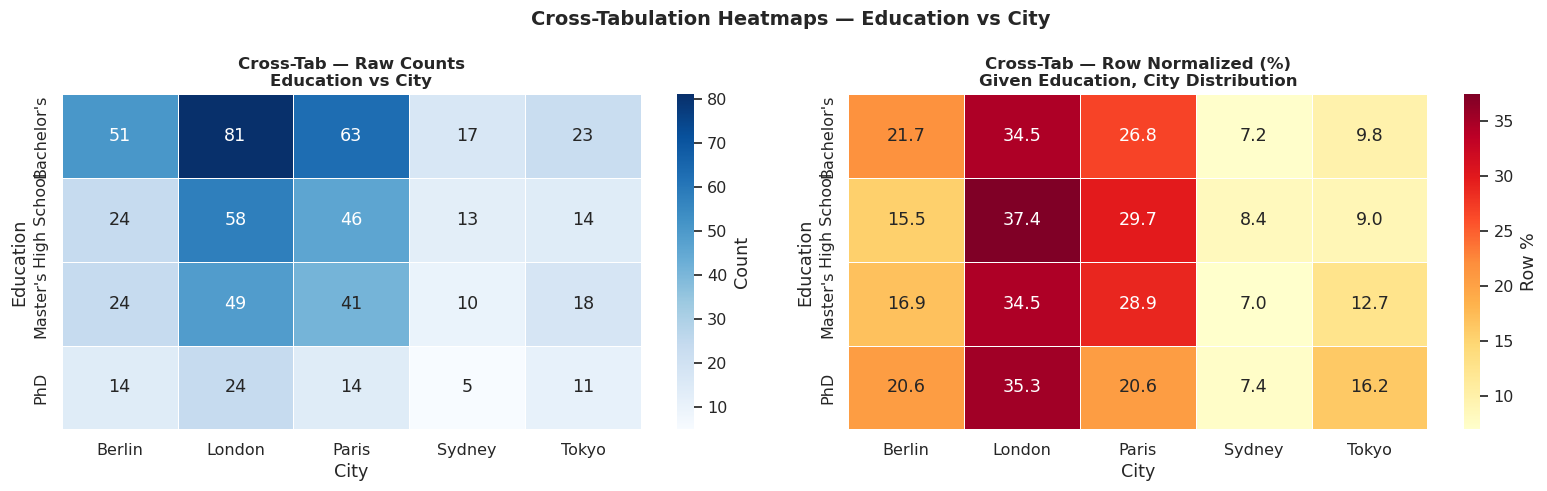

In [11]:
# Raw count cross-tab
ct_raw = pd.crosstab(df['Education'], df['City'],
                     rownames=['Education'], colnames=['City'],
                     margins=True)
print('Cross-Tabulation — Education vs City (Raw Counts):')
print(ct_raw)

# Row-normalized cross-tab
ct_norm = pd.crosstab(df['Education'], df['City'], normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(ct_raw.iloc[:-1, :-1],  # exclude margins
            annot=True, fmt='d',
            cmap='Blues', linewidths=0.5,
            ax=axes[0],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Cross-Tab — Raw Counts\nEducation vs City',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Education')

sns.heatmap(ct_norm.round(1),
            annot=True, fmt='.1f',
            cmap='YlOrRd', linewidths=0.5,
            ax=axes[1],
            cbar_kws={'label': 'Row %'})
axes[1].set_title('Cross-Tab — Row Normalized (%)\nGiven Education, City Distribution',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Education')

plt.suptitle('Cross-Tabulation Heatmaps — Education vs City',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9️⃣ Stacked & Grouped Bar Charts

> **Stacked** — shows the composition of each group (parts of a whole).  
> **Grouped** — allows direct side-by-side count comparison across categories.

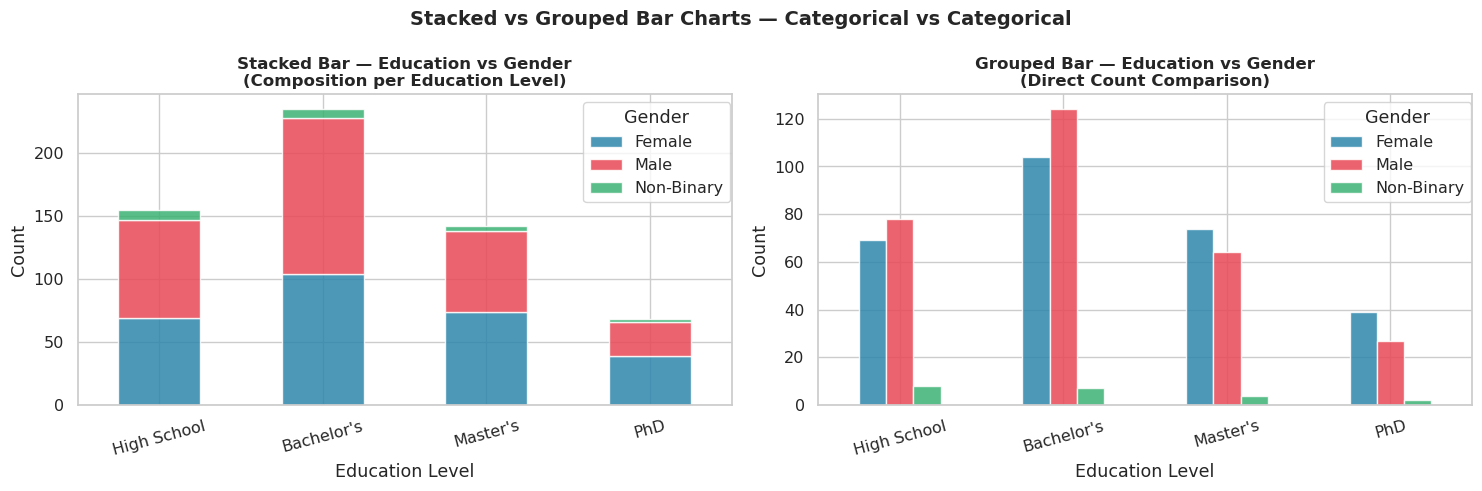

In [12]:
ct_plot = pd.crosstab(df['Education'], df['Gender']).reindex(edu_order)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Stacked
ct_plot.plot(
    kind='bar', stacked=True,
    color=COLORS['palette'][:3],
    edgecolor='white', ax=axes[0], alpha=0.85
)
axes[0].set_title('Stacked Bar — Education vs Gender\n(Composition per Education Level)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Education Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Gender', bbox_to_anchor=(1.01, 1))

# Grouped
ct_plot.plot(
    kind='bar', stacked=False,
    color=COLORS['palette'][:3],
    edgecolor='white', ax=axes[1], alpha=0.85
)
axes[1].set_title('Grouped Bar — Education vs Gender\n(Direct Count Comparison)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Education Level')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Gender', bbox_to_anchor=(1.01, 1))

plt.suptitle('Stacked vs Grouped Bar Charts — Categorical vs Categorical',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔟 Chi-Square Test + Cramér's V

> **Chi-Square** tests statistical independence between two categorical variables.  
> **Cramér's V** quantifies the strength of that association (0 = none, 1 = perfect).

In [13]:
def cramers_v(ct):
    chi2 = chi2_contingency(ct)[0]
    n    = ct.sum().sum()
    r, c = ct.shape
    return np.sqrt(chi2 / (n * (min(r, c) - 1)))

cat_pairs = [
    ('Education', 'City'),
    ('Education', 'Gender'),
    ('City',      'Gender'),
]

chi2_rows = []
for col_a, col_b in cat_pairs:
    ct                  = pd.crosstab(df[col_a], df[col_b])
    chi2, p, dof, exp   = chi2_contingency(ct)
    v                   = cramers_v(ct)

    def v_interp(v):
        if v < 0.10: return 'Negligible'
        if v < 0.30: return 'Weak'
        if v < 0.50: return 'Moderate'
        return 'Strong'

    chi2_rows.append({
        'Variable A'     : col_a,
        'Variable B'     : col_b,
        'χ² Statistic'   : round(chi2, 4),
        'Degrees of Freedom': dof,
        'p-value'        : round(p, 4),
        'Significant'    : '✅' if p < 0.05 else '❌',
        "Cramér's V"     : round(v, 4),
        'Association'    : v_interp(v),
    })

chi2_df = pd.DataFrame(chi2_rows)
print('Chi-Square Test + Cramér\'s V Summary:')
chi2_df

Chi-Square Test + Cramér's V Summary:


,Variable A,Variable B,χ² Statistic,Degrees of Freedom,p-value,Significant,Cramér's V,Association
0,Education,City,7.3067,12,0.8367,❌,0.0637,Negligible
1,Education,Gender,6.8650,6,0.3335,❌,0.0756,Negligible
2,City,Gender,8.6530,8,0.3724,❌,0.0849,Negligible


---
## PART D — Feature vs Target (ML-Focused EDA)
---
## 1️⃣1️⃣ KDE by Target Class — Numerical Feature vs Target

> Overlays the KDE of a numerical feature for each target class.  
> **Separated peaks = strong predictive signal. Overlapping = weak signal.**

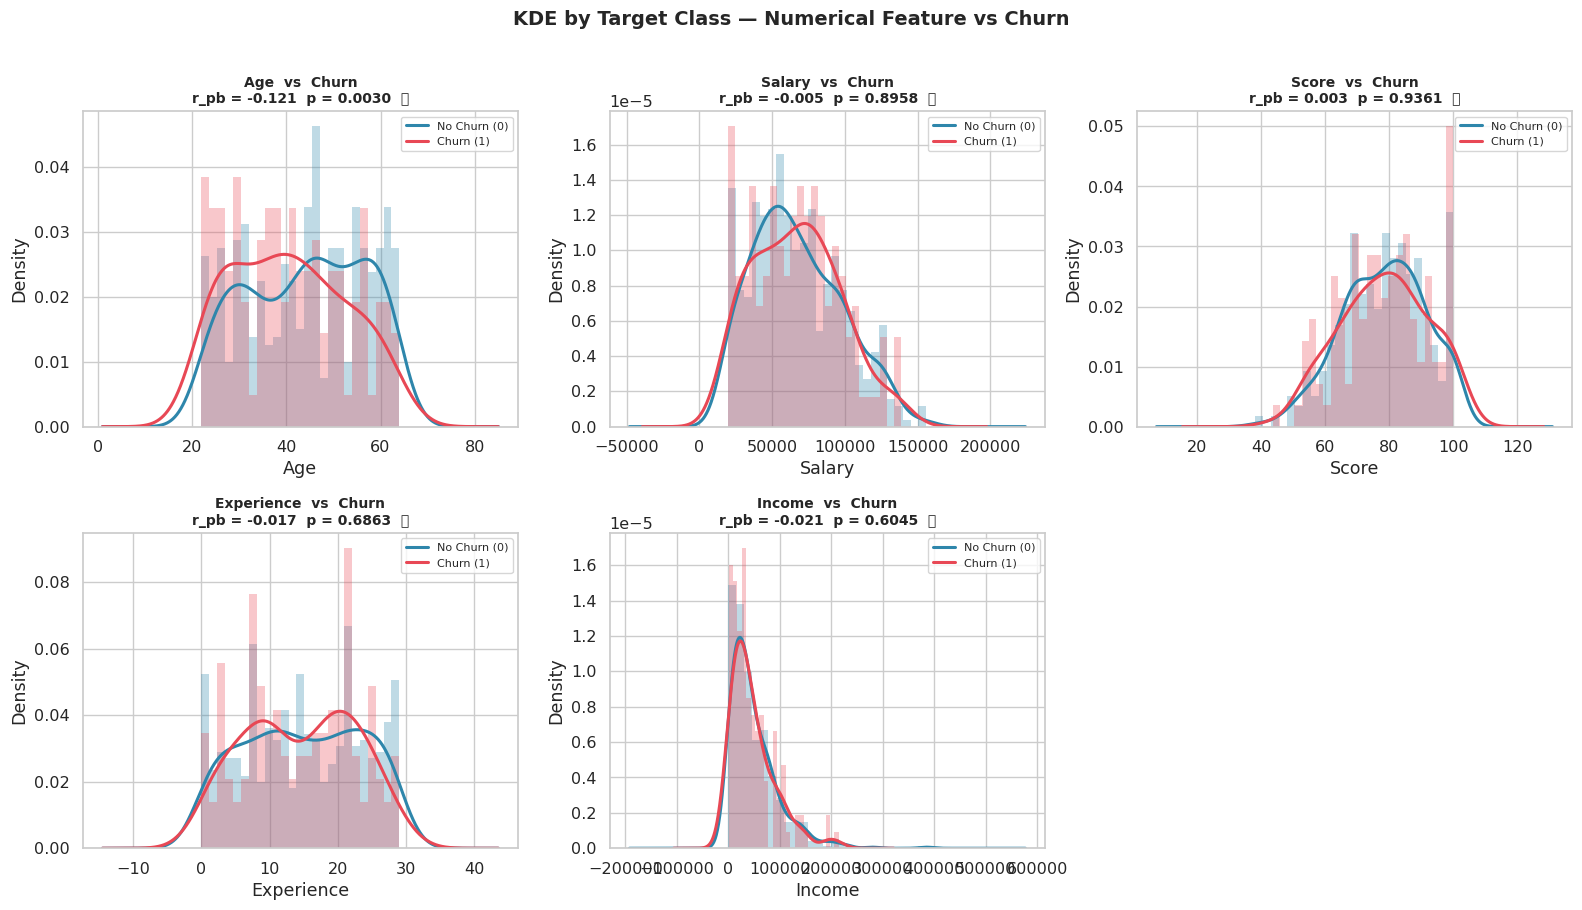

In [14]:
num_features = ['Age', 'Salary', 'Score', 'Experience', 'Income']
n_cols = 3
n_rows = int(np.ceil(len(num_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, num_features):
    for churn_val, color, label in [
        (0, COLORS['primary'],   'No Churn (0)'),
        (1, COLORS['secondary'], 'Churn (1)')
    ]:
        data = df[df[target] == churn_val][col].dropna()
        ax.hist(data, bins=25, density=True, alpha=0.3, color=color, edgecolor='none')
        data.plot.kde(ax=ax, color=color, linewidth=2.2, label=label)

    # Point-biserial correlation
    corr, p_val = pointbiserialr(df[col].dropna(),
                                  df.loc[df[col].notna(), target])
    sig = '✅' if p_val < 0.05 else '❌'
    ax.set_title(f'{col}  vs  Churn\nr_pb = {corr:.3f}  p = {p_val:.4f}  {sig}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

for ax in axes[len(num_features):]:
    ax.set_visible(False)

plt.suptitle('KDE by Target Class — Numerical Feature vs Churn',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 1️⃣2️⃣ Churn Rate by Category — Categorical Feature vs Target

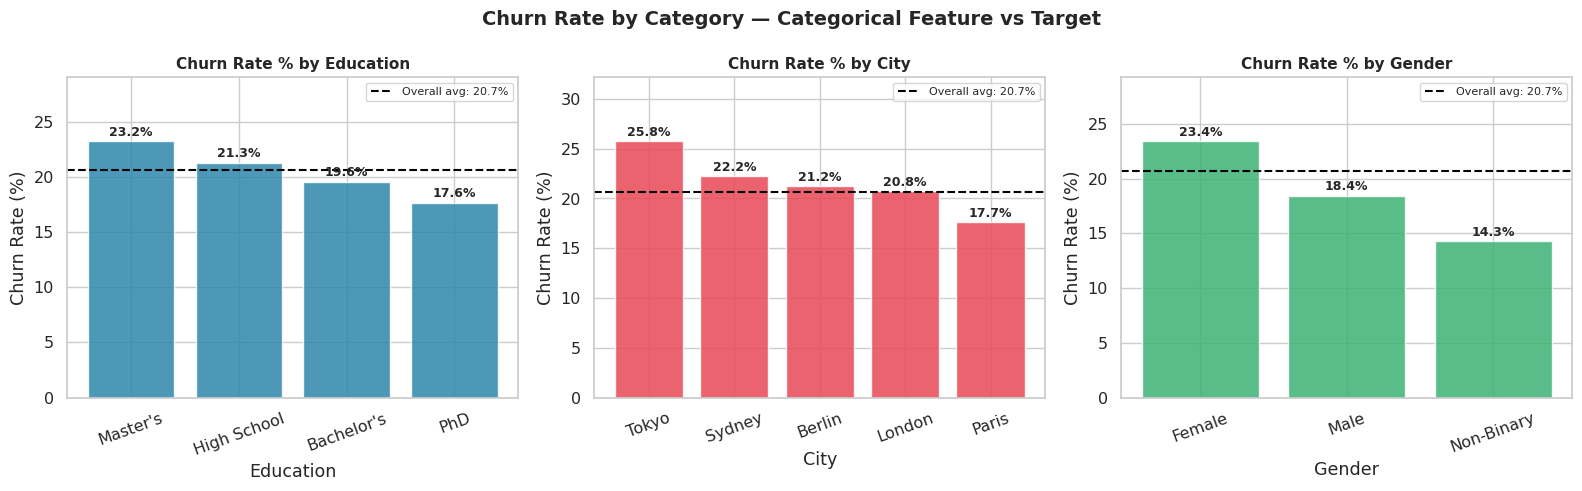

In [15]:
fig, axes = plt.subplots(1, len(cat_cols), figsize=(16, 5))

for ax, col, color in zip(axes, cat_cols, COLORS['palette']):
    churn_rate = (df.groupby(col)[target].mean() * 100).sort_values(ascending=False)
    bars = ax.bar(churn_rate.index, churn_rate.values,
                  color=color, edgecolor='white', alpha=0.85)
    overall = df[target].mean() * 100
    ax.axhline(overall, color='black', linestyle='--', linewidth=1.5,
               label=f'Overall avg: {overall:.1f}%')
    ax.set_title(f'Churn Rate % by {col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=20)
    ax.legend(fontsize=8)
    ax.set_ylim(0, churn_rate.max() * 1.25)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Churn Rate by Category — Categorical Feature vs Target',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 1️⃣3️⃣ Point-Biserial Correlation — All Numerical vs Binary Target

Point-Biserial Correlation — All Numerical Features vs Churn:
     Feature    r_pb  |r_pb|  p-value Significant  Direction   Strength
         Age -0.1209  0.1209   0.0030           ✅ ↓ Negative       Weak
Num_Products  0.0689  0.0689   0.0918           ❌ ↑ Positive Negligible
      Income -0.0212  0.0212   0.6045           ❌ ↓ Negative Negligible
  Experience -0.0165  0.0165   0.6863           ❌ ↓ Negative Negligible
      Salary -0.0054  0.0054   0.8958           ❌ ↓ Negative Negligible
       Score  0.0033  0.0033   0.9361           ❌ ↑ Positive Negligible


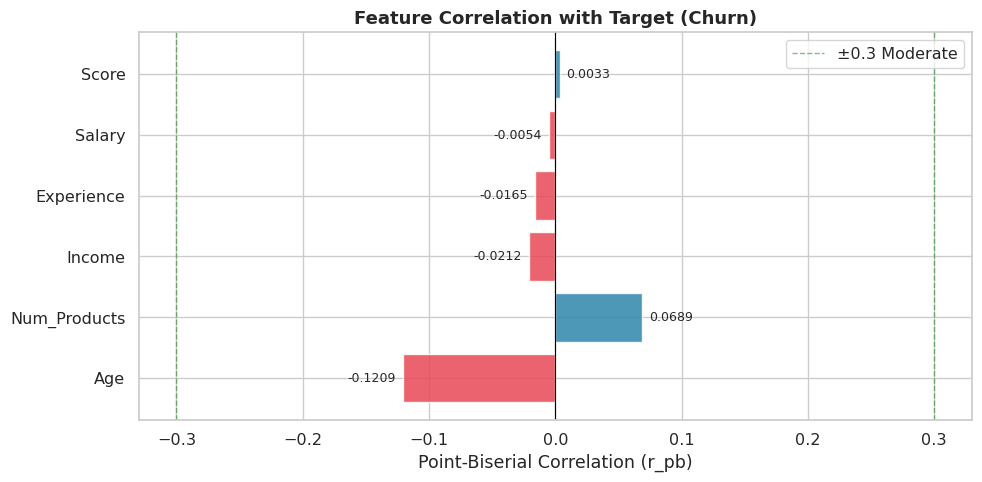

In [16]:
pb_rows = []
for col in num_cols:
    data = df[[col, target]].dropna()
    corr, p_val = pointbiserialr(data[col], data[target])
    pb_rows.append({
        'Feature'         : col,
        'r_pb'            : round(corr, 4),
        '|r_pb|'          : round(abs(corr), 4),
        'p-value'         : round(p_val, 4),
        'Significant'     : '✅' if p_val < 0.05 else '❌',
        'Direction'       : '↑ Positive' if corr > 0 else '↓ Negative',
        'Strength'        : ('Strong' if abs(corr) >= 0.5 else
                             'Moderate' if abs(corr) >= 0.3 else
                             'Weak' if abs(corr) >= 0.1 else 'Negligible'),
    })

pb_df = pd.DataFrame(pb_rows).sort_values('|r_pb|', ascending=False)
print('Point-Biserial Correlation — All Numerical Features vs Churn:')
print(pb_df.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = [COLORS['primary'] if v >= 0 else COLORS['secondary']
          for v in pb_df['r_pb']]
bars = ax.barh(pb_df['Feature'], pb_df['r_pb'],
               color=colors, edgecolor='white', alpha=0.85)
ax.axvline(0,    color='black', linewidth=0.8)
ax.axvline(0.3,  color='green', linewidth=1, linestyle='--', alpha=0.5, label='±0.3 Moderate')
ax.axvline(-0.3, color='green', linewidth=1, linestyle='--', alpha=0.5)
for bar, val in zip(bars, pb_df['r_pb']):
    xpos = bar.get_width() + (0.005 if val >= 0 else -0.005)
    ha   = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha=ha, fontsize=9)
ax.set_xlabel('Point-Biserial Correlation (r_pb)')
ax.set_title('Feature Correlation with Target (Churn)',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 📋 14. Automated Bivariate EDA Report

In [17]:
def bivariate_eda_report(df, num_cols, cat_cols, target):
    """
    Generates a comprehensive bivariate EDA summary for all
    numerical features vs the binary target variable.
    """
    rows = []

    # Numerical vs Target (point-biserial)
    for col in num_cols:
        data = df[[col, target]].dropna()
        corr, p = pointbiserialr(data[col], data[target])
        grp0 = data[data[target] == 0][col]
        grp1 = data[data[target] == 1][col]
        _, t_p = ttest_ind(grp0, grp1)

        rows.append({
            'Feature'       : col,
            'Type'          : 'Numerical',
            'r_pb'          : round(corr, 4),
            '|r_pb|'        : round(abs(corr), 4),
            'p (r_pb)'      : round(p, 4),
            'p (t-test)'    : round(t_p, 4),
            'Significant'   : '✅' if p < 0.05 else '❌',
            'Mean (No Churn)': round(grp0.mean(), 2),
            'Mean (Churn)'  : round(grp1.mean(), 2),
            'Recommendation': (
                'Strong predictor — include' if abs(corr) >= 0.3 else
                'Moderate signal — keep for now' if abs(corr) >= 0.1 else
                'Weak signal — consider dropping'
            )
        })

    # Categorical vs Target (churn rate spread)
    for col in cat_cols:
        churn_rates = df.groupby(col)[target].mean() * 100
        ct = pd.crosstab(df[col], df[target])
        chi2, p, _, _ = chi2_contingency(ct)
        v = np.sqrt(chi2 / (df.shape[0] * (min(ct.shape) - 1)))

        rows.append({
            'Feature'       : col,
            'Type'          : 'Categorical',
            'r_pb'          : 'N/A',
            '|r_pb|'        : round(v, 4),
            'p (r_pb)'      : round(p, 4),
            'p (t-test)'    : 'N/A',
            'Significant'   : '✅' if p < 0.05 else '❌',
            'Mean (No Churn)': f'{churn_rates.min():.1f}%',
            'Mean (Churn)'  : f'{churn_rates.max():.1f}%',
            'Recommendation': (
                'Strong predictor (Cramér V ≥ 0.3) — include' if v >= 0.3 else
                'Weak predictor — review categories' if v >= 0.1 else
                'Negligible association — consider dropping'
            )
        })

    report = (pd.DataFrame(rows)
                .sort_values('|r_pb|', ascending=False)
                .reset_index(drop=True))
    return report


report = bivariate_eda_report(df, num_cols, cat_cols, target)
print('📋 Bivariate EDA Report — All Features vs Churn:')
report

📋 Bivariate EDA Report — All Features vs Churn:


,Feature,Type,r_pb,|r_pb|,p (r_pb),p (t-test),Significant,Mean (No Churn),Mean (Churn),Recommendation
0,Age,Numerical,-0.1209,0.1209,0.0030,0.0030,✅,44.1200,40.4300,Moderate signal — keep for now
1,Num_Products,Numerical,0.0689,0.0689,0.0918,0.0918,❌,7.4600,8.1400,Weak signal — consider dropping
2,Gender,Categorical,N/A,0.0676,0.2536,N/A,❌,14.3%,23.4%,Negligible association — consider dropping
3,City,Categorical,N/A,0.0581,0.7314,N/A,❌,17.7%,25.8%,Negligible association — consider dropping
4,Education,Categorical,N/A,0.0440,0.7628,N/A,❌,17.6%,23.2%,Negligible association — consider dropping
5,Income,Numerical,-0.0212,0.0212,0.6045,0.6045,❌,50130.2700,47692.9400,Weak signal — consider dropping
6,Experience,Numerical,-0.0165,0.0165,0.6863,0.6863,❌,14.8200,14.4800,Weak signal — consider dropping
7,Salary,Numerical,-0.0054,0.0054,0.8958,0.8958,❌,67424.9800,67023.6600,Weak signal — consider dropping
8,Score,Numerical,0.0033,0.0033,0.9361,0.9361,❌,78.2300,78.3400,Weak signal — consider dropping


---
## ✅ 15. Summary & Best Practices

| Pair Type | Visualization | Statistical Test |
|-----------|:-------------:|:----------------:|
| **Num vs Num** | Scatter + Regression Line | Pearson r / Spearman ρ |
| **Num vs Cat** | Box Plot / Violin / Bar ± CI | t-Test / Mann-Whitney / ANOVA / Kruskal |
| **Cat vs Cat** | Crosstab Heatmap / Stacked Bar | Chi-Square + Cramér's V |
| **Num vs Target** | KDE by Class / Box by Class | Point-Biserial Correlation |
| **Cat vs Target** | Churn Rate Bar Chart | Chi-Square + Cramér's V |

### 🔑 Golden Rules

1. **Always plot before computing** — a scatter reveals patterns a single number cannot
2. **Correlation ≠ causation** — never assume one variable causes another
3. **Use Spearman when Pearson and Spearman diverge** — indicates non-linearity
4. **Always pair p-value with effect size** — statistical ≠ practical significance
5. **Normalize cross-tabs** — raw counts mislead when group sizes differ
6. **Chi-square needs expected counts ≥ 5** — merge rare categories if needed
7. **KDE by class is the fastest ML signal check** — separated peaks = useful feature

---

## 🔗 Next Steps

- ➡️ `Multivariate_Analysis/` — Extend to 3+ variables (pair plots, 3D scatter, parallel coords)
- ➡️ `Correlation_Analysis/` — Full pairwise correlation heatmap across all features
- ➡️ `Feature_Engineering/` — Use bivariate insights to create interaction features
- ➡️ `06_Feature_Selection/` — Drop features with negligible correlation to target